# ST1504 CA2 Part B: Pendulum Control Using Reinforcement Learning

## Objective

The objective is to develop and evaluate a suitable Deep Q-Network modification for controlling the Pendulum environment under four gravity conditions:

- Free-fall, (g=0)
- Anti-gravity, (g=-10)
- Default gravity, (g=10)
- Supergravity, (g=15)

Two group members independently develop different DQN candidates. Both candidates use the same common training configuration and are tested under all four gravities. This controlled design ensures that the final architecture is selected based on model behaviour rather than different experimental settings.

This notebook contains Kayden's candidate: **Double DQN + Dueling Network + Prioritized Experience Replay**. A standard DQN baseline is retained to demonstrate whether the candidate provides a meaningful improvement.


In [1]:
import gym
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from collections import deque
from tensorflow.keras import layers

print("Gym version:", gym.__version__)
print("TensorFlow version:", tf.__version__)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Gym version: 0.25.2
TensorFlow version: 2.10.0


## Environment Setup

Unlike supervised learning tasks, reinforcement learning does not begin with a fixed dataset. Instead, training data is generated through interactions between the agent and its environment.

The OpenAI Gym Pendulum environment is created as the data source for this project. During each interaction, the environment provides the agent with a state. The agent selects an action, receives a reward and observes the resulting next state.

The default gravity setting will first be used to explore the environment and develop the baseline DQN agent.

In [2]:
env = gym.make("Pendulum-v1")

state = env.reset()

print("Environment:", env)
print("Initial state:", state)
print("State shape:", state.shape)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Default gravity:", env.unwrapped.g)

env.close()

Environment: <TimeLimit<OrderEnforcing<StepAPICompatibility<PassiveEnvChecker<PendulumEnv<Pendulum-v1>>>>>>
Initial state: [-0.56870925  0.8225386   0.8843571 ]
State shape: (3,)
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Default gravity: 10.0


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


# Exploratory Data Analysis (EDA)
### Environment Structure

The Pendulum environment represents each state using three numerical observations:

- The cosine of the pendulum angle
- The sine of the pendulum angle
- The angular velocity of the pendulum

The first two observations range from **-1 to 1**, while angular velocity ranges from **-8 to 8**. Each state therefore has a shape of **(3,)**.

The original action consists of one continuous torque value ranging from **-2 to 2**. Since DQN requires discrete actions, this action space will later be discretised during preprocessing.

Each episode has a maximum duration of **200 time steps**.

In [3]:
env = gym.make("Pendulum-v1")

print("Observation shape:", env.observation_space.shape)
print("Observation minimum values:", env.observation_space.low)
print("Observation maximum values:", env.observation_space.high)

print("Action shape:", env.action_space.shape)
print("Action minimum value:", env.action_space.low)
print("Action maximum value:", env.action_space.high)

print("Maximum episode length:", env.spec.max_episode_steps)
print("Gravity:", env.unwrapped.g)

env.close()

Observation shape: (3,)
Observation minimum values: [-1. -1. -8.]
Observation maximum values: [1. 1. 8.]
Action shape: (1,)
Action minimum value: [-2.]
Action maximum value: [2.]
Maximum episode length: 200
Gravity: 10.0


### Collection of Random-Agent Interaction Data

Unlike a traditional dataset, reinforcement learning data is generated when an agent interacts with the environment.

A random agent was used to complete multiple episodes. At each time step, the following information was recorded:

- Current state
- Selected torque
- Reward received
- Total episodic return

This exploratory data will be used to examine the distributions of the observations, actions and rewards before developing the DQN agent.

In [4]:
env = gym.make("Pendulum-v1")
state = env.reset(seed=42)

number_of_episodes = 50

collected_states = []
collected_actions = []
collected_rewards = []
episode_returns = []

for episode in range(number_of_episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = env.action_space.sample()

        next_state, reward, done, info = env.step(action)

        collected_states.append(state)
        collected_actions.append(action[0])
        collected_rewards.append(reward)

        total_reward += reward
        state = next_state

    episode_returns.append(total_reward)

env.close()

collected_states = np.array(collected_states)
collected_actions = np.array(collected_actions)
collected_rewards = np.array(collected_rewards)
episode_returns = np.array(episode_returns)

print("Collected states:", collected_states.shape)
print("Collected actions:", collected_actions.shape)
print("Collected rewards:", collected_rewards.shape)
print("Episode returns:", episode_returns.shape)

Collected states: (10000, 3)
Collected actions: (10000,)
Collected rewards: (10000,)
Episode returns: (50,)


### Interaction Data Quality

The randomly collected states, actions and rewards were checked for missing and infinite values.

Reinforcement learning environments normally generate valid numerical observations. However, this check is still important because invalid values could cause unstable gradients or prevent the DQN from training correctly.

If no missing or infinite values are found, all collected interactions can be retained for exploratory analysis.

In [5]:
print(
    "Missing state values:",
    np.isnan(collected_states).sum()
)

print(
    "Infinite state values:",
    np.isinf(collected_states).sum()
)

print(
    "Missing action values:",
    np.isnan(collected_actions).sum()
)

print(
    "Infinite action values:",
    np.isinf(collected_actions).sum()
)

print(
    "Missing reward values:",
    np.isnan(collected_rewards).sum()
)

print(
    "Infinite reward values:",
    np.isinf(collected_rewards).sum()
)

Missing state values: 0
Infinite state values: 0
Missing action values: 0
Infinite action values: 0
Missing reward values: 0
Infinite reward values: 0


### Distribution of State Observations

The distributions of the three state observations were examined using histograms.

The cosine and sine observations describe the pendulum’s angular position, while angular velocity describes the speed and direction of its rotation.

This analysis helps identify the ranges and distributions experienced by a random agent. It also indicates whether state normalisation may be useful before DQN training.

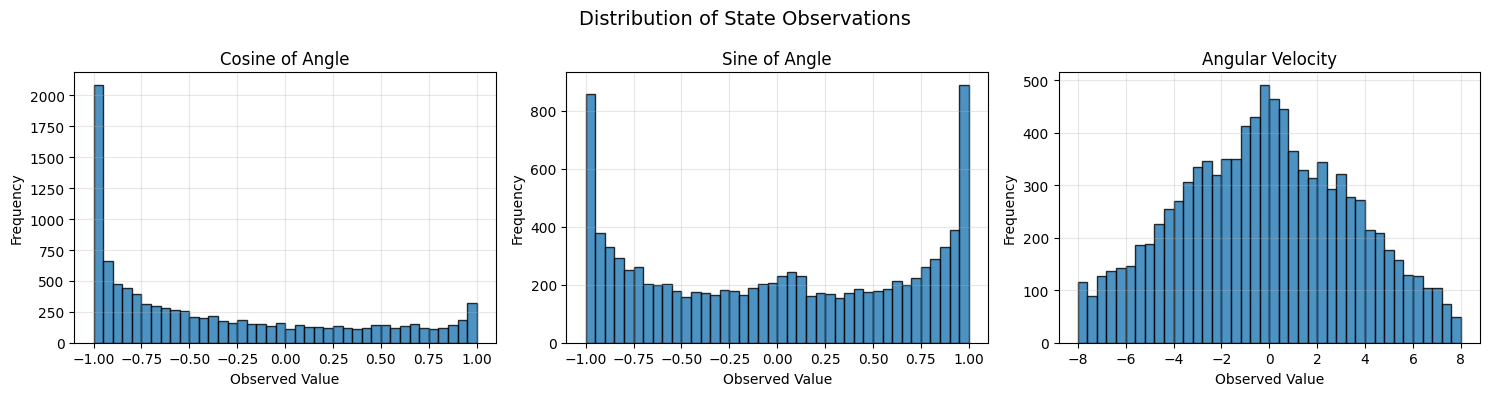

In [6]:
state_names = [
    "Cosine of Angle",
    "Sine of Angle",
    "Angular Velocity"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

for index, axis in enumerate(axes):
    axis.hist(
        collected_states[:, index],
        bins=40,
        alpha=0.8,
        edgecolor="black"
    )

    axis.set_title(state_names[index])
    axis.set_xlabel("Observed Value")
    axis.set_ylabel("Frequency")
    axis.grid(alpha=0.3)

plt.suptitle(
    "Distribution of State Observations",
    fontsize=14
)

plt.tight_layout()
plt.show()

#### Interpretation of State Distributions

The cosine observation is strongly concentrated near **-1**. Since a cosine value of -1 represents the pendulum pointing downwards, this shows that the random agent frequently allows the pendulum to remain near its natural hanging position. In comparison, the desired upright position has a cosine value near **1**.

The sine observation covers the complete range from -1 to 1, showing that the pendulum moves through positions on both sides of its rotation.

Angular velocity is approximately centred around zero and ranges from about -8 to 8. Its numerical range is considerably wider than the cosine and sine observations, which are limited to -1 to 1. Therefore, scaling angular velocity may help ensure that it does not have a disproportionately large influence during DQN training.

### Distribution of Random Actions and Rewards

The distributions of the randomly selected torque values and the resulting rewards were examined.

Since the actions were sampled randomly from the continuous action space, torque values across the range of -2 to 2 are expected. The reward distribution provides a baseline indication of the performance achieved without learning.

For the Pendulum environment, rewards are negative. Values closer to zero represent better control of the pendulum.

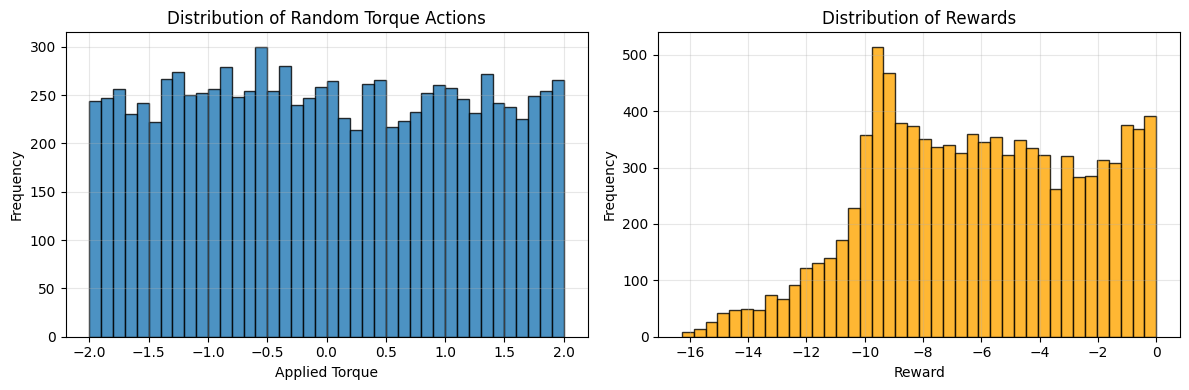

In [7]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].hist(
    collected_actions,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

axes[0].set_title("Distribution of Random Torque Actions")
axes[0].set_xlabel("Applied Torque")
axes[0].set_ylabel("Frequency")
axes[0].grid(alpha=0.3)

axes[1].hist(
    collected_rewards,
    bins=40,
    edgecolor="black",
    alpha=0.8,
    color="orange"
)

axes[1].set_title("Distribution of Rewards")
axes[1].set_xlabel("Reward")
axes[1].set_ylabel("Frequency")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Random Actions and Rewards

The random torque actions are distributed approximately evenly across the complete range from **-2 to 2**. This confirms that the random agent does not favour any particular torque value or direction.

The per-step rewards range from approximately **-16 to 0**, with most rewards occurring around -10 to -4. Since the maximum possible reward is zero, the mainly negative distribution indicates that the random agent generally fails to keep the pendulum upright and stable.

A smaller number of rewards appear close to zero, showing that the pendulum occasionally reaches a favourable position by chance. However, the random agent cannot maintain this position consistently because it does not learn from previous interactions.

These results provide a baseline that the trained DQN agent should improve upon by achieving rewards that are more consistently concentrated closer to zero.

### Initial Comparison of Gravity Conditions

The Pendulum environment was explored under the four gravity conditions required by the assignment:

- Default gravity, \(g = 10\)
- Free-fall, \(g = 0\)
- Anti-gravity, \(g = -10\)
- Supergravity, \(g = 15\)

A random agent was evaluated under each condition to examine how gravity affects the environment before DQN training.

The same number of episodes and random seed were used for every gravity condition to make the comparison fair. These results represent untrained baseline performance and will later be compared with the trained DQN agents.

In [8]:
gravity_settings = {
    "Default": 10.0,
    "Free-fall": 0.0,
    "Anti-gravity": -10.0,
    "Supergravity": 15.0
}

episodes_per_gravity = 30
gravity_baseline_returns = {}

for gravity_name, gravity_value in gravity_settings.items():
    env = gym.make("Pendulum-v1")
    env.unwrapped.g = gravity_value

    env.seed(42)
    env.action_space.seed(42)

    condition_returns = []

    for episode in range(episodes_per_gravity):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = env.action_space.sample()

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

        condition_returns.append(total_reward)

    gravity_baseline_returns[gravity_name] = np.array(
        condition_returns
    )

    env.close()

    print(
        gravity_name,
        "- Mean:",
        np.mean(condition_returns),
        "- Standard deviation:",
        np.std(condition_returns)
    )

c:\Users\kayde\anaconda3\envs\st1504_rl\lib\site-packages\gym\core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is marked as deprecated and will be removed in the future. Please use `env.reset(seed=seed)` instead.
  deprecation(


Default - Mean: -1189.63307601102 - Standard deviation: 231.64725307533595
Free-fall - Mean: -748.6178031504127 - Standard deviation: 184.61422238394752
Anti-gravity - Mean: -602.1183430727535 - Standard deviation: 396.9365950877032
Supergravity - Mean: -1386.837203404409 - Standard deviation: 124.56566538166022


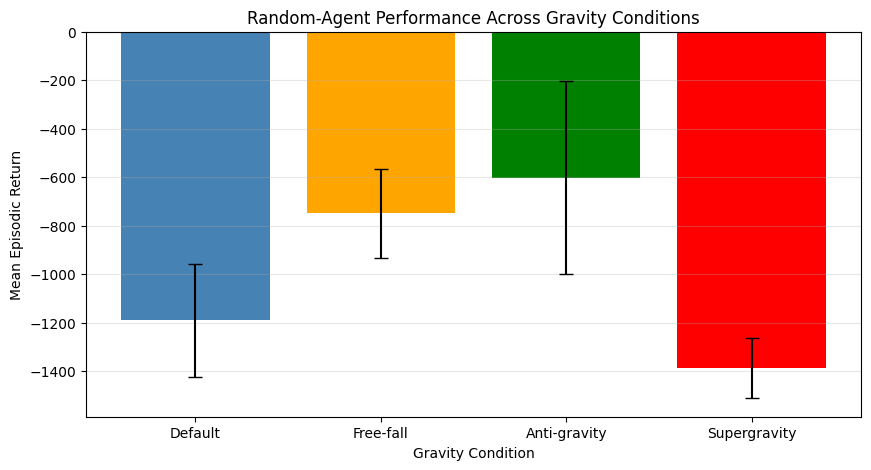

In [9]:
gravity_names = list(gravity_baseline_returns.keys())

mean_returns = [
    gravity_baseline_returns[name].mean()
    for name in gravity_names
]

return_standard_deviations = [
    gravity_baseline_returns[name].std()
    for name in gravity_names
]

plt.figure(figsize=(10, 5))

plt.bar(
    gravity_names,
    mean_returns,
    yerr=return_standard_deviations,
    capsize=5,
    color=["steelblue", "orange", "green", "red"]
)

plt.title("Random-Agent Performance Across Gravity Conditions")
plt.xlabel("Gravity Condition")
plt.ylabel("Mean Episodic Return")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation of Gravity Baselines

The random agent achieved different levels of performance under the four gravity conditions.

Free-fall produced the highest mean episodic return, with an average of approximately **-760**. Without gravitational force pulling the pendulum downwards, the random agent was more likely to remain in comparatively favourable positions.

Anti-gravity produced the second-highest mean return of approximately **-850**. However, it also had the largest standard deviation, indicating that its performance varied considerably between episodes.

The default-gravity condition produced a lower mean return of approximately **-1350**, while supergravity produced the lowest mean return of approximately **-1480**. The stronger gravitational force in supergravity makes it more difficult for randomly selected torque actions to move and maintain the pendulum near the upright position.

The overlapping error bars show that random-agent performance varies between episodes. Therefore, multiple evaluation episodes should also be used when comparing trained DQN agents.

Each trained agent should be compared against the random baseline from the same gravity condition because the four environments have different levels of difficulty.

In [10]:
# EDA: Verify Custom Gravity Testing Compatibility
gravity_test_values = [10.0, 0.0, -10.0, 15.0]

print("Testing dynamic gravity configuration:")
for g in gravity_test_values:
    test_env = gym.make("Pendulum-v1")
    test_env.unwrapped.g = g
    test_env.reset()
    
    # Execute 1 dummy step
    _, reward, _, _ = test_env.step(test_env.action_space.sample())
    print(f"  Gravity set to {g:5.1f} | Sample Step Reward: {reward:.4f}")
    test_env.close()

Testing dynamic gravity configuration:
  Gravity set to  10.0 | Sample Step Reward: -0.3682
  Gravity set to   0.0 | Sample Step Reward: -2.8561
  Gravity set to -10.0 | Sample Step Reward: -7.4018
  Gravity set to  15.0 | Sample Step Reward: -3.0926


## Data Preprocessing

The exploratory analysis found no missing or infinite values in the environment observations, actions or rewards. Therefore, no interaction data needs to be removed or imputed.

However, two preprocessing steps are required before DQN can be applied:

1. Discretise the continuous torque action space.
2. Scale the state observations to a similar numerical range.

These transformations will make the Pendulum environment suitable for training with a Deep Q-Network.

# Observation Normalization Function

In [11]:
import numpy as np

# Preprocessing: State Observation Scaler
def normalize_state(state):
    """
    Normalize Pendulum state to approximately [-1, 1].

    State format:
        state[0] = cos(theta)  -> already in [-1, 1]
        state[1] = sin(theta)  -> already in [-1, 1]
        state[2] = theta_dot   -> expected in [-8, 8]

    Returns:
        Normalized state as float32.
    """
    state = np.asarray(state, dtype=np.float32).copy()

    # Scale angular velocity
    state[2] = np.clip(state[2] / 8.0, -1.0, 1.0)

    return state

sample_raw_state = np.array([0.5, -0.5, 6.0], dtype=np.float32)
sample_norm_state = normalize_state(sample_raw_state)

print("Raw State Sample        :", sample_raw_state)
print("Normalized State Sample :", sample_norm_state)

Raw State Sample        : [ 0.5 -0.5  6. ]
Normalized State Sample : [ 0.5  -0.5   0.75]


### Action-Space Discretisation

Pendulum has a continuous torque range from −2 to 2, while DQN requires discrete actions. The common configuration divides this interval into **40 evenly spaced torque actions**.

The same 40-action mapping is used for the baseline, Kayden's candidate and the other group member's candidate during model selection. Although an even number of actions does not contain exactly zero torque, it provides two small actions close to zero and maintains the agreed controlled configuration.


In [12]:
action_env = gym.make("Pendulum-v1")
ACTION_LOW = float(action_env.action_space.low[0])
ACTION_HIGH = float(action_env.action_space.high[0])
action_env.close()


def create_action_values(num_actions):
    return np.linspace(
        ACTION_LOW,
        ACTION_HIGH,
        int(num_actions),
        dtype=np.float32
    )


def action_index_to_torque(action_index, action_values):
    action_index = int(action_index)

    if not 0 <= action_index < len(action_values):
        raise ValueError("Action index is outside the discretised action space.")

    return np.array(
        [action_values[action_index]],
        dtype=np.float32
    )


common_action_values = create_action_values(40)

print("Number of discrete actions:", len(common_action_values))
print("Minimum torque:", common_action_values.min())
print("Maximum torque:", common_action_values.max())
print("Two actions closest to zero:", common_action_values[19:21])


Number of discrete actions: 40
Minimum torque: -2.0
Maximum torque: 2.0
Two actions closest to zero: [-0.05128205  0.05128205]


### State Casting and Scaling

The state contains three observations with different numerical ranges:

- Cosine of angle: −1 to 1
- Sine of angle: −1 to 1
- Angular velocity: −8 to 8

Angular velocity is divided by 8 so that all three features are approximately within −1 to 1. The states are also converted to `float32`, which is suitable for TensorFlow training.


In [13]:
state_scale = np.array(
    [1.0, 1.0, 8.0],
    dtype=np.float32
)


def preprocess_state(state):
    state = np.asarray(state, dtype=np.float32)
    scaled_state = state / state_scale
    return np.clip(scaled_state, -1.0, 1.0)


In [14]:
env = gym.make("Pendulum-v1")
original_state = env.reset()
original_state = original_state[0] if isinstance(original_state, tuple) else original_state
processed_state = preprocess_state(original_state)
env.close()

print("Original state:", original_state)
print("Processed state:", processed_state)
print("Processed datatype:", processed_state.dtype)


Original state: [ 0.00597394  0.9999822  -0.82240933]
Processed state: [ 0.00597394  0.9999822  -0.10280117]
Processed datatype: float32


In [15]:
processed_collected_states = np.array([
    preprocess_state(state)
    for state in collected_states
])

print("Original minimum values:", collected_states.min(axis=0))
print("Original maximum values:", collected_states.max(axis=0))
print("Processed minimum values:", processed_collected_states.min(axis=0))
print("Processed maximum values:", processed_collected_states.max(axis=0))


Original minimum values: [-1. -1. -8.]
Original maximum values: [0.99999976 0.9999998  8.        ]
Processed minimum values: [-1. -1. -1.]
Processed maximum values: [0.99999976 0.9999998  1.        ]


### Verification of State Preprocessing

Before preprocessing, cosine and sine were already within −1 to 1, while angular velocity ranged from −8 to 8. After scaling, all three observations are within approximately −1 to 1. Small differences from the exact limits are caused by floating-point precision and do not require correction.


## Modelling and Controlled Experimental Design

The modelling process has three stages:

1. **Candidate development:** each group member creates a different DQN modification.
2. **Controlled comparison:** both candidates use the same common configuration and are trained under all four gravities.
3. **Final tuning:** after one architecture is selected, its hyperparameters may be tuned separately for each gravity.

During the current stage, no gravity-specific hyperparameter tuning is performed. This keeps the architecture comparison fair.


### Locked Common Configuration

The following settings are fixed for the baseline and both candidate architectures during model selection. `min_replay_memory` delays gradient updates until 1,000 transitions have been collected. `target_update_every = 1` synchronises the target network after every episode.


In [16]:
COMMON_CONFIG = {
    "episodes": 150,
    "gamma": 0.99,

    "epsilon": 1.0,
    "epsilon_min": 0.01,
    "epsilon_decay": 0.98,

    "hidden_size": 64,
    "num_actions": 40,

    "batch_size": 32,
    "replay_memory_size": 10000,
    "min_replay_memory": 1000,

    "target_update_every": 1,
    "learning_rate": 0.001
}

GRAVITY_SETTINGS = {
    "Free-fall": 0.0,
    "Anti-gravity": -10.0,
    "Default": 10.0,
    "Supergravity": 15.0
}

# PER introduces algorithm-specific parameters that have no baseline equivalent.
CANDIDATE_SPECIFIC_CONFIG = {
    "per_alpha": 0.6,
    "per_beta_start": 0.4,
    "per_beta_increment": 0.00005
}

print("Locked common configuration:")
for key, value in COMMON_CONFIG.items():
    print(f"{key:<24}: {value}")

print("\nGravity conditions:")
for gravity_name, gravity in GRAVITY_SETTINGS.items():
    print(f"{gravity_name:<15}: g={gravity}")


Locked common configuration:
episodes                : 150
gamma                   : 0.99
epsilon                 : 1.0
epsilon_min             : 0.01
epsilon_decay           : 0.98
hidden_size             : 64
num_actions             : 40
batch_size              : 32
replay_memory_size      : 10000
min_replay_memory       : 1000
target_update_every     : 1
learning_rate           : 0.001

Gravity conditions:
Free-fall      : g=0.0
Anti-gravity   : g=-10.0
Default        : g=10.0
Supergravity   : g=15.0


### Environment and Training Helpers

The helper functions support both Gym step APIs and preprocess every observation before it enters a network. Raw training values are displayed faintly in the graphs, while a 10-episode moving average shows the overall trend.


In [17]:
def create_env(gravity):
    return gym.make(
        "Pendulum-v1",
        g=float(gravity),
        new_step_api=True
    )


def reset_environment(env, seed=None):
    result = env.reset(seed=seed) if seed is not None else env.reset()
    state = result[0] if isinstance(result, tuple) else result
    return preprocess_state(state)


def step_environment(env, action):
    result = env.step(action)

    if len(result) == 5:
        next_state, reward, terminated, truncated, info = result
        done = terminated or truncated
    else:
        next_state, reward, done, info = result

    return preprocess_state(next_state), float(reward), bool(done), info


def moving_average(values, window=10):
    values = np.asarray(values, dtype=np.float32)

    if len(values) < window:
        return values

    return np.convolve(
        values,
        np.ones(window, dtype=np.float32) / window,
        mode="valid"
    )


GRAVITY_COLOURS = {
    "Free-fall": "tab:orange",
    "Anti-gravity": "tab:green",
    "Default": "tab:blue",
    "Supergravity": "tab:red"
}


def plot_training_history(results, metric, ylabel, title, window=10):
    if not results:
        print("Train the agents before plotting this graph.")
        return

    plt.figure(figsize=(12, 6))

    for gravity_name in GRAVITY_SETTINGS:
        values = np.asarray(results[gravity_name][metric], dtype=np.float32)
        valid_mask = np.isfinite(values)
        valid_values = values[valid_mask]
        valid_episodes = np.arange(1, len(values) + 1)[valid_mask]

        plt.plot(
            valid_episodes,
            valid_values,
            color=GRAVITY_COLOURS[gravity_name],
            alpha=0.12
        )

        if len(valid_values) >= window:
            smoothed = moving_average(valid_values, window)
            plt.plot(
                valid_episodes[window - 1:],
                smoothed,
                color=GRAVITY_COLOURS[gravity_name],
                linewidth=2,
                label=f"{gravity_name} ({window}-episode average)"
            )

    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 1. Standard DQN Baseline

The baseline uses two 64-unit hidden layers, a uniform replay buffer, a target network and epsilon-greedy exploration. Its output contains 40 Q-values corresponding to the common discrete torque actions.

The standard DQN target uses the largest target-network Q-value for the next state. Mean squared error measures the difference between predicted and target Q-values.


In [18]:
class DQNAgent:
    def __init__(self, state_dim, action_dim, config):
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)
        self.gamma = float(config["gamma"])
        self.learning_rate = float(config["learning_rate"])
        self.hidden_size = int(config["hidden_size"])

        self.epsilon = float(config["epsilon"])
        self.epsilon_min = float(config["epsilon_min"])
        self.epsilon_decay = float(config["epsilon_decay"])

        self.batch_size = int(config["batch_size"])
        self.min_replay_memory = int(config["min_replay_memory"])
        self.memory = deque(maxlen=int(config["replay_memory_size"]))

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_network()

    def _build_model(self):
        model = tf.keras.Sequential([
            layers.Input(shape=(self.state_dim,)),
            layers.Dense(self.hidden_size, activation="relu"),
            layers.Dense(self.hidden_size, activation="relu"),
            layers.Dense(self.action_dim, activation="linear")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=self.learning_rate
            ),
            loss="mse"
        )
        return model

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state, explore=True):
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        q_values = self.model(
            tf.convert_to_tensor(state[None, :], dtype=tf.float32),
            training=False
        )
        return int(tf.argmax(q_values[0]).numpy())

    def replay(self):
        if len(self.memory) < self.min_replay_memory:
            return None

        minibatch = random.sample(self.memory, self.batch_size)

        states = np.asarray([item[0] for item in minibatch], dtype=np.float32)
        actions = np.asarray([item[1] for item in minibatch], dtype=np.int32)
        rewards = np.asarray([item[2] for item in minibatch], dtype=np.float32)
        next_states = np.asarray([item[3] for item in minibatch], dtype=np.float32)
        dones = np.asarray([item[4] for item in minibatch], dtype=np.float32)

        training_targets = self.model(states, training=False).numpy()
        target_next_q = self.target_model(next_states, training=False).numpy()
        target_values = (
            rewards
            + (1.0 - dones) * self.gamma * np.max(target_next_q, axis=1)
        )

        training_targets[
            np.arange(self.batch_size),
            actions
        ] = target_values

        loss = self.model.train_on_batch(states, training_targets)
        return float(np.asarray(loss).reshape(-1)[0])


## 2. Kayden's Candidate: Dueling Double DQN with PER

The candidate changes the learning algorithm while retaining all agreed common settings:

- **Double DQN:** the online network selects the next action and the target network evaluates it, reducing overestimation.
- **Dueling architecture:** separate streams estimate state value and action advantages.
- **Prioritized Experience Replay:** transitions with larger temporal-difference errors are sampled more often.
- **Huber loss:** reduces sensitivity to unusually large errors.

These are the only substantive differences from the baseline during controlled model selection.


### Prioritized Experience Replay Buffer


In [19]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.capacity = int(capacity)
        self.alpha = float(alpha)
        self.buffer = []
        self.priorities = np.zeros(self.capacity, dtype=np.float32)
        self.position = 0

    def add(self, transition):
        maximum_priority = (
            self.priorities[:len(self.buffer)].max()
            if self.buffer else 1.0
        )

        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.position] = transition

        self.priorities[self.position] = max(float(maximum_priority), 1e-5)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size, beta):
        valid_priorities = self.priorities[:len(self.buffer)]
        scaled_priorities = valid_priorities ** self.alpha
        probabilities = scaled_priorities / scaled_priorities.sum()

        indices = np.random.choice(
            len(self.buffer),
            size=batch_size,
            replace=True,
            p=probabilities
        )
        samples = [self.buffer[index] for index in indices]

        weights = (len(self.buffer) * probabilities[indices]) ** (-beta)
        weights /= weights.max()

        return samples, indices, weights.astype(np.float32)

    def update_priorities(self, indices, priorities):
        for index, priority in zip(indices, priorities):
            self.priorities[index] = max(float(priority), 1e-5)

    def __len__(self):
        return len(self.buffer)


### Dueling Double-DQN Agent


In [20]:
class ImprovedDQNAgent:
    def __init__(self, state_dim, action_dim, config):
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)
        self.gamma = float(config["gamma"])
        self.learning_rate = float(config["learning_rate"])
        self.hidden_size = int(config["hidden_size"])

        self.epsilon = float(config["epsilon"])
        self.epsilon_min = float(config["epsilon_min"])
        self.epsilon_decay = float(config["epsilon_decay"])

        self.batch_size = int(config["batch_size"])
        self.min_replay_memory = int(config["min_replay_memory"])
        self.memory = PrioritizedReplayBuffer(
            capacity=config["replay_memory_size"],
            alpha=config["per_alpha"]
        )

        self.beta = float(config["per_beta_start"])
        self.beta_increment = float(config["per_beta_increment"])

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_network()

    def _build_model(self):
        inputs = layers.Input(shape=(self.state_dim,))

        features = layers.Dense(
            self.hidden_size,
            activation="relu"
        )(inputs)
        features = layers.Dense(
            self.hidden_size,
            activation="relu"
        )(features)

        state_value = layers.Dense(
            self.hidden_size,
            activation="relu"
        )(features)
        state_value = layers.Dense(1)(state_value)

        action_advantages = layers.Dense(
            self.hidden_size,
            activation="relu"
        )(features)
        action_advantages = layers.Dense(
            self.action_dim
        )(action_advantages)

        centred_advantages = layers.Lambda(
            lambda values: values - tf.reduce_mean(
                values,
                axis=1,
                keepdims=True
            )
        )(action_advantages)

        q_values = layers.Lambda(
            lambda tensors: tensors[0] + tensors[1]
        )([state_value, centred_advantages])

        model = tf.keras.Model(inputs=inputs, outputs=q_values)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=self.learning_rate
            ),
            loss=tf.keras.losses.Huber()
        )
        return model

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.add((state, action, reward, next_state, done))

    def act(self, state, explore=True):
        if explore and np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        q_values = self.model(
            tf.convert_to_tensor(state[None, :], dtype=tf.float32),
            training=False
        )
        return int(tf.argmax(q_values[0]).numpy())

    def replay(self):
        if len(self.memory) < self.min_replay_memory:
            return None

        minibatch, indices, weights = self.memory.sample(
            self.batch_size,
            beta=self.beta
        )

        states = np.asarray([item[0] for item in minibatch], dtype=np.float32)
        actions = np.asarray([item[1] for item in minibatch], dtype=np.int32)
        rewards = np.asarray([item[2] for item in minibatch], dtype=np.float32)
        next_states = np.asarray([item[3] for item in minibatch], dtype=np.float32)
        dones = np.asarray([item[4] for item in minibatch], dtype=np.float32)

        current_q = self.model(states, training=False).numpy()

        # Double DQN: online network selects, target network evaluates.
        online_next_q = self.model(next_states, training=False).numpy()
        best_next_actions = np.argmax(online_next_q, axis=1)
        target_next_q = self.target_model(next_states, training=False).numpy()
        selected_next_q = target_next_q[
            np.arange(self.batch_size),
            best_next_actions
        ]

        target_values = (
            rewards
            + (1.0 - dones) * self.gamma * selected_next_q
        )

        previous_values = current_q[
            np.arange(self.batch_size),
            actions
        ].copy()

        training_targets = current_q.copy()
        training_targets[
            np.arange(self.batch_size),
            actions
        ] = target_values

        td_errors = np.abs(target_values - previous_values)
        self.memory.update_priorities(indices, td_errors + 1e-5)

        loss = self.model.train_on_batch(
            states,
            training_targets,
            sample_weight=weights
        )

        self.beta = min(1.0, self.beta + self.beta_increment)
        return float(np.asarray(loss).reshape(-1)[0])


## Shared Training Procedure

Both models are trained with seed 42 and identical common settings. An agent is created separately for each gravity. Episode return, mean episode loss and epsilon are recorded.

A checkpoint is saved whenever the latest 10-episode average return improves. The strongest checkpoint is restored before validation, preventing the final comparison from depending only on the last training episode.


In [21]:
def build_gravity_config(gravity, candidate=False):
    config = {
        **COMMON_CONFIG,
        "gravity": float(gravity)
    }

    if candidate:
        config.update(CANDIDATE_SPECIFIC_CONFIG)

    return config


def train_agent(
    gravity_name,
    config,
    agent_class,
    model_label,
    seed=42
):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    env = create_env(config["gravity"])
    action_values = create_action_values(config["num_actions"])

    agent = agent_class(
        state_dim=env.observation_space.shape[0],
        action_dim=config["num_actions"],
        config=config
    )

    episode_returns = []
    episode_losses = []
    epsilon_history = []
    best_moving_return = -np.inf

    gravity_slug = (
        gravity_name.lower()
        .replace("-", "_")
        .replace(" ", "_")
    )
    checkpoint_path = (
        f"best_{model_label.lower()}_{gravity_slug}.h5"
    )

    print(
        f"\nTraining {model_label} | {gravity_name} "
        f"(g={config['gravity']})"
    )

    for episode in range(1, config["episodes"] + 1):
        state = reset_environment(env, seed=seed + episode)
        done = False
        total_reward = 0.0
        step_losses = []

        while not done:
            action_index = agent.act(state, explore=True)
            torque = action_index_to_torque(action_index, action_values)
            next_state, reward, done, _ = step_environment(env, torque)

            agent.remember(
                state,
                action_index,
                reward,
                next_state,
                done
            )

            loss = agent.replay()
            if loss is not None:
                step_losses.append(loss)

            state = next_state
            total_reward += reward

        episode_returns.append(total_reward)
        episode_losses.append(
            np.mean(step_losses) if step_losses else np.nan
        )
        epsilon_history.append(agent.epsilon)

        agent.epsilon = max(
            agent.epsilon_min,
            agent.epsilon * agent.epsilon_decay
        )

        if episode % config["target_update_every"] == 0:
            agent.update_target_network()

        if len(episode_returns) >= 10:
            latest_average = np.mean(episode_returns[-10:])

            if latest_average > best_moving_return:
                best_moving_return = latest_average
                agent.model.save_weights(checkpoint_path)

        if episode == 1 or episode % 10 == 0:
            print(
                f"Episode {episode:3d}/{config['episodes']} | "
                f"Return: {total_reward:8.2f} | "
                f"Loss: {episode_losses[-1]:8.4f} | "
                f"Epsilon: {agent.epsilon:.3f}"
            )

    env.close()

    agent.model.load_weights(checkpoint_path)
    agent.update_target_network()

    return {
        "agent": agent,
        "returns": np.asarray(episode_returns, dtype=np.float32),
        "losses": np.asarray(episode_losses, dtype=np.float32),
        "epsilon": np.asarray(epsilon_history, dtype=np.float32),
        "best_moving_return": float(best_moving_return),
        "checkpoint_path": checkpoint_path,
        "action_values": action_values,
        "config": config.copy()
    }


## Baseline Training Across All Four Gravities

This cell trains four separate baseline agents. It is computationally expensive and should not be rerun unless necessary.


In [22]:
RUN_BASELINE_TRAINING = True
baseline_results = {}

if RUN_BASELINE_TRAINING:
    for gravity_name, gravity in GRAVITY_SETTINGS.items():
        baseline_results[gravity_name] = train_agent(
            gravity_name=gravity_name,
            config=build_gravity_config(gravity, candidate=False),
            agent_class=DQNAgent,
            model_label="Baseline",
            seed=42
        )
else:
    print("Set RUN_BASELINE_TRAINING = True to train all baselines.")


c:\Users\kayde\anaconda3\envs\st1504_rl\lib\random.py:370: DeprecationWarning: non-integer arguments to randrange() have been deprecated since Python 3.10 and will be removed in a subsequent version
  return self.randrange(a, b+1)



Training Baseline | Free-fall (g=0.0)
Episode   1/150 | Return:  -471.75 | Loss:      nan | Epsilon: 0.980
Episode  10/150 | Return:  -112.39 | Loss:   0.0376 | Epsilon: 0.817
Episode  20/150 | Return:  -100.52 | Loss:   0.0870 | Epsilon: 0.668
Episode  30/150 | Return:   -73.28 | Loss:   0.2063 | Epsilon: 0.545
Episode  40/150 | Return:  -178.73 | Loss:   0.1780 | Epsilon: 0.446
Episode  50/150 | Return:    -9.83 | Loss:   0.0930 | Epsilon: 0.364
Episode  60/150 | Return:   -76.19 | Loss:   0.0577 | Epsilon: 0.298
Episode  70/150 | Return:   -74.53 | Loss:   0.0634 | Epsilon: 0.243
Episode  80/150 | Return:   -55.69 | Loss:   0.0319 | Epsilon: 0.199
Episode  90/150 | Return:   -54.52 | Loss:   0.0505 | Epsilon: 0.162
Episode 100/150 | Return:  -151.64 | Loss:   0.0511 | Epsilon: 0.133
Episode 110/150 | Return:   -73.07 | Loss:   0.0355 | Epsilon: 0.108
Episode 120/150 | Return:  -129.09 | Loss:   0.0519 | Epsilon: 0.089
Episode 130/150 | Return:   -42.74 | Loss:   0.0596 | Epsilon: 0

### Baseline Reward and Loss Graphs

Returns closer to zero indicate better control. Loss is used to inspect numerical stability and should not be used as the final performance metric.


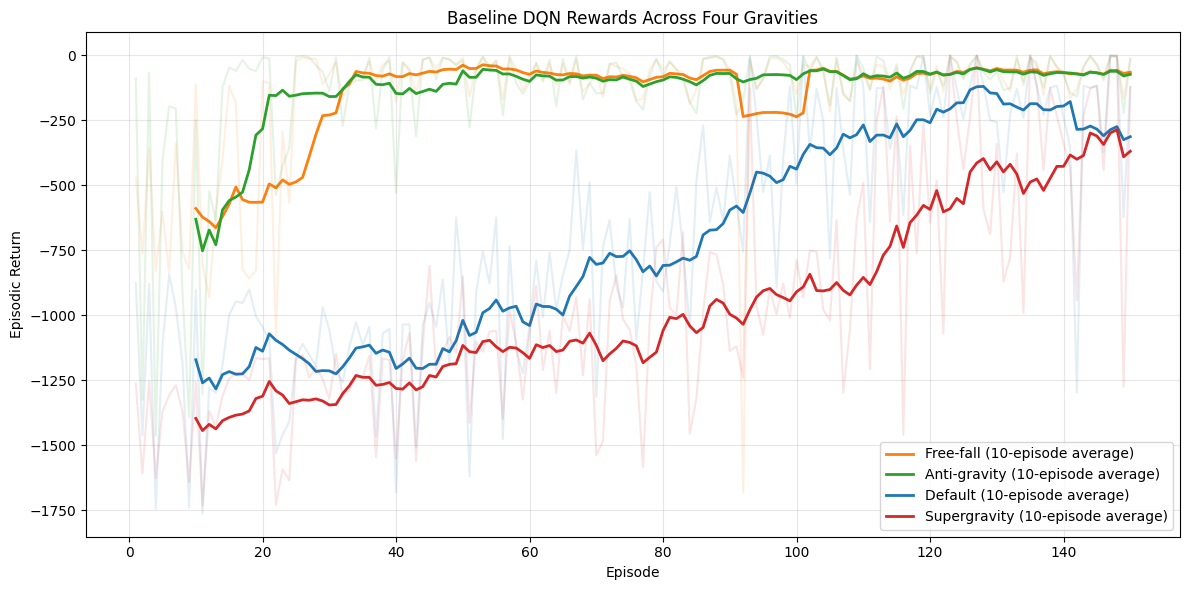

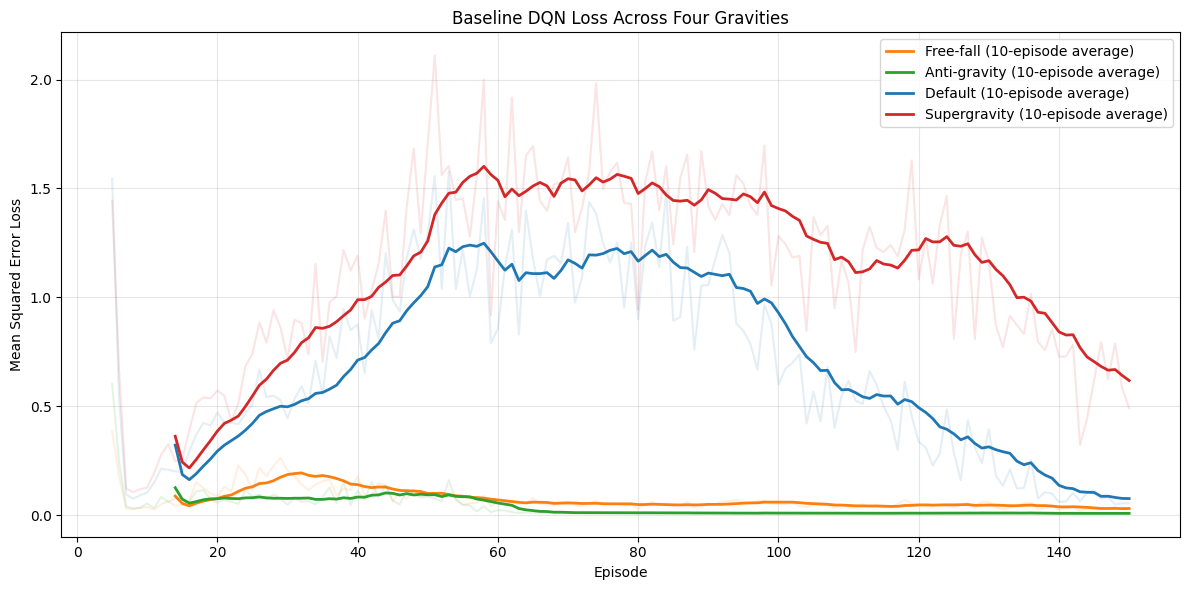

In [23]:
plot_training_history(
    baseline_results,
    metric="returns",
    ylabel="Episodic Return",
    title="Baseline DQN Rewards Across Four Gravities"
)

plot_training_history(
    baseline_results,
    metric="losses",
    ylabel="Mean Squared Error Loss",
    title="Baseline DQN Loss Across Four Gravities"
)


## Candidate Training Across All Four Gravities

This cell trains four separate instances of Kayden's candidate using exactly the same common settings as the baseline.


In [24]:
RUN_CANDIDATE_TRAINING = True
candidate_results = {}

if RUN_CANDIDATE_TRAINING:
    for gravity_name, gravity in GRAVITY_SETTINGS.items():
        candidate_results[gravity_name] = train_agent(
            gravity_name=gravity_name,
            config=build_gravity_config(gravity, candidate=True),
            agent_class=ImprovedDQNAgent,
            model_label="KaydenCandidate",
            seed=42
        )
else:
    print("Set RUN_CANDIDATE_TRAINING = True to train the candidate agents.")



Training KaydenCandidate | Free-fall (g=0.0)
Episode   1/150 | Return:  -471.75 | Loss:      nan | Epsilon: 0.980
Episode  10/150 | Return:  -652.77 | Loss:   0.0066 | Epsilon: 0.817
Episode  20/150 | Return:   -19.94 | Loss:   0.0087 | Epsilon: 0.668
Episode  30/150 | Return:   -67.16 | Loss:   0.0049 | Epsilon: 0.545
Episode  40/150 | Return:  -208.99 | Loss:   0.0028 | Epsilon: 0.446
Episode  50/150 | Return:    -8.39 | Loss:   0.0016 | Epsilon: 0.364
Episode  60/150 | Return:   -75.03 | Loss:   0.0003 | Epsilon: 0.298
Episode  70/150 | Return:   -69.07 | Loss:   0.0002 | Epsilon: 0.243
Episode  80/150 | Return:   -45.39 | Loss:   0.0002 | Epsilon: 0.199
Episode  90/150 | Return:   -53.53 | Loss:   0.0001 | Epsilon: 0.162
Episode 100/150 | Return:  -127.04 | Loss:   0.0002 | Epsilon: 0.133
Episode 110/150 | Return:   -43.10 | Loss:   0.0001 | Epsilon: 0.108
Episode 120/150 | Return:  -130.79 | Loss:   0.0001 | Epsilon: 0.089
Episode 130/150 | Return:   -44.77 | Loss:   0.0001 | Eps

### Candidate Reward and Loss Graphs

Candidate loss uses Huber loss and is therefore not numerically comparable with the baseline MSE loss. Evaluation return remains the primary comparison metric.


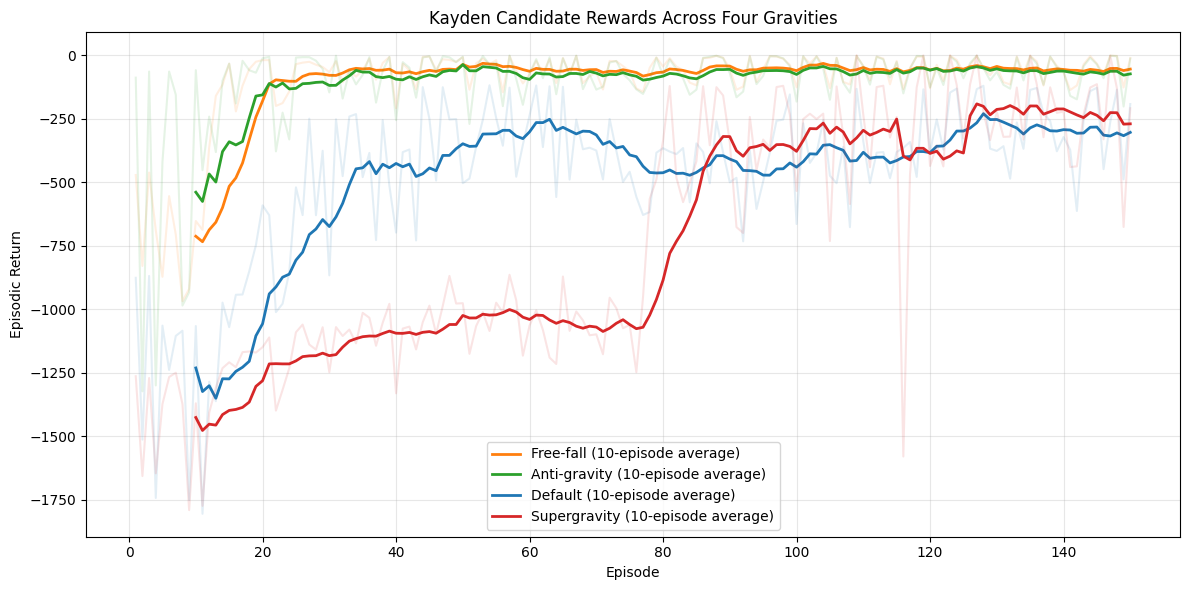

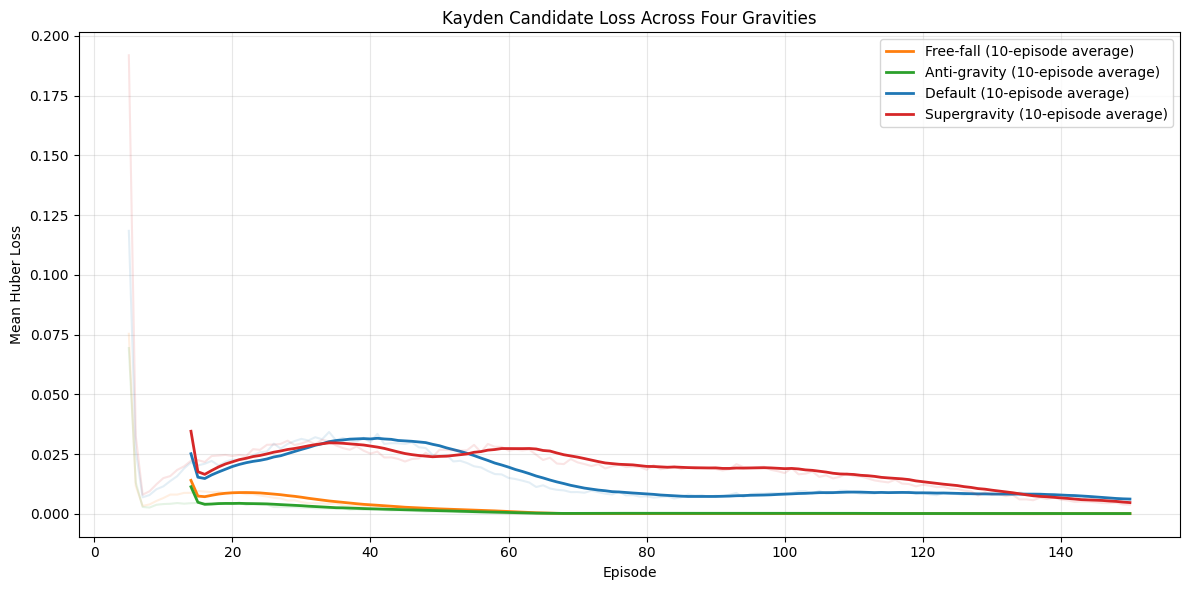

In [25]:
plot_training_history(
    candidate_results,
    metric="returns",
    ylabel="Episodic Return",
    title="Kayden Candidate Rewards Across Four Gravities"
)

plot_training_history(
    candidate_results,
    metric="losses",
    ylabel="Mean Huber Loss",
    title="Kayden Candidate Loss Across Four Gravities"
)


## Baseline and Candidate Learning Curves

Each subplot compares the 10-episode moving-average return under one gravity. These curves show learning speed and stability, while the controlled validation section provides the final quantitative comparison.


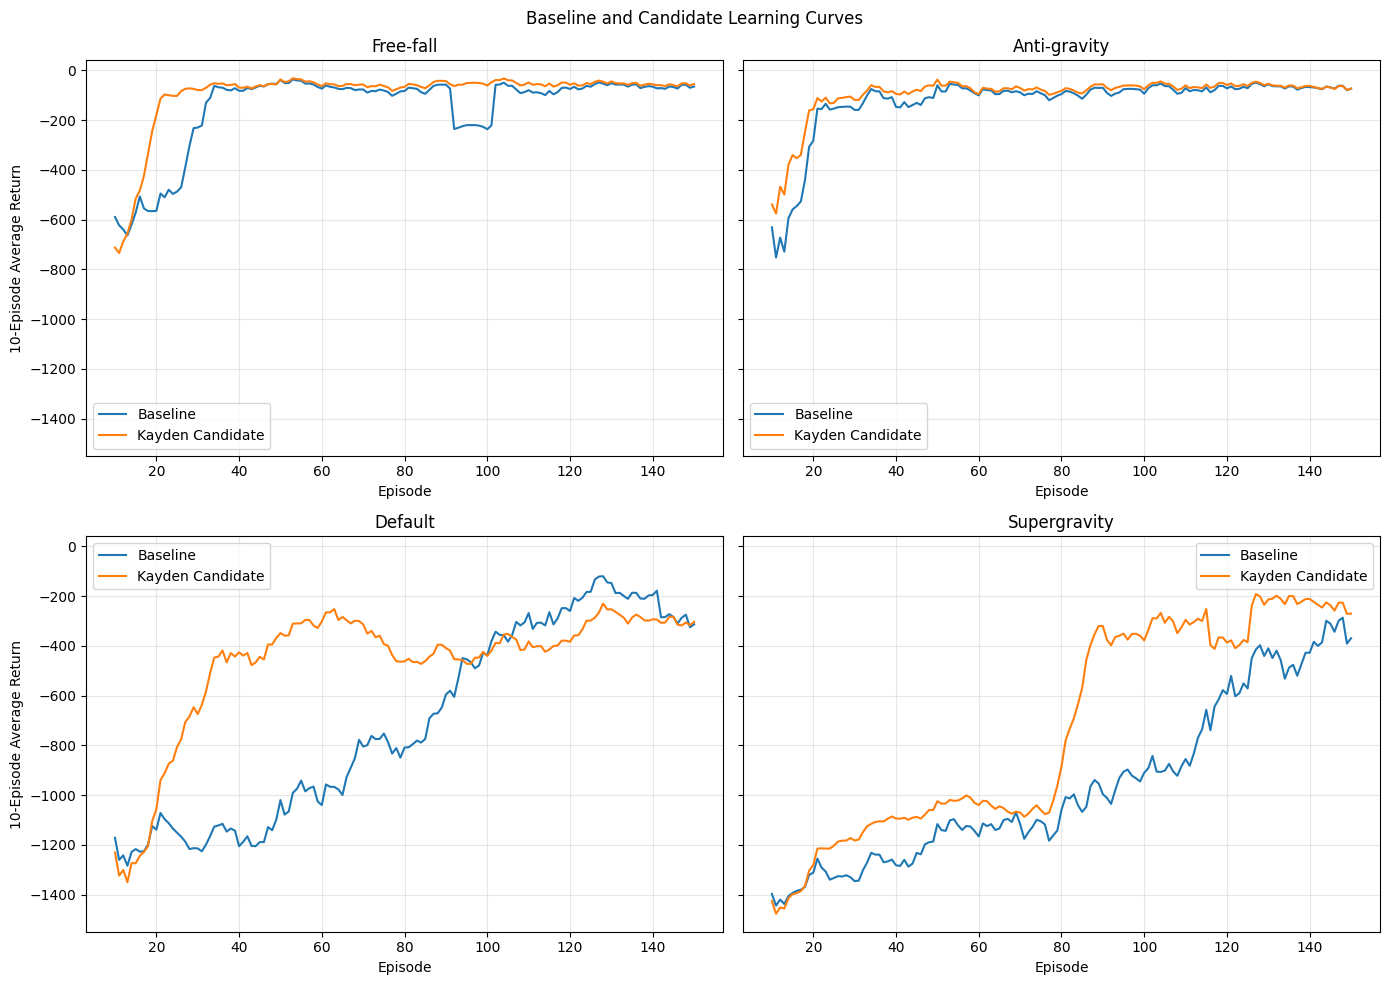

In [26]:
if baseline_results and candidate_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

    for axis, gravity_name in zip(axes.flat, GRAVITY_SETTINGS):
        baseline_curve = moving_average(
            baseline_results[gravity_name]["returns"],
            window=10
        )
        candidate_curve = moving_average(
            candidate_results[gravity_name]["returns"],
            window=10
        )

        axis.plot(
            np.arange(10, 10 + len(baseline_curve)),
            baseline_curve,
            label="Baseline"
        )
        axis.plot(
            np.arange(10, 10 + len(candidate_curve)),
            candidate_curve,
            label="Kayden Candidate"
        )

        axis.set_title(gravity_name)
        axis.set_xlabel("Episode")
        axis.grid(alpha=0.3)
        axis.legend()

    axes[0, 0].set_ylabel("10-Episode Average Return")
    axes[1, 0].set_ylabel("10-Episode Average Return")
    plt.suptitle("Baseline and Candidate Learning Curves")
    plt.tight_layout()
    plt.show()


## Controlled Validation

The best checkpoints are evaluated using validation seeds 1000–1019 with exploration disabled. The networks and replay buffers are not updated. These seeds are used for model development and comparison only.

Final test seeds 2000–2029 are reserved until the group has selected one architecture and completed gravity-specific fine-tuning. This prevents the final evaluation from influencing model selection.


In [27]:
def evaluate_agent(training_result, evaluation_seeds):
    agent = training_result["agent"]
    config = training_result["config"]
    action_values = training_result["action_values"]
    env = create_env(config["gravity"])

    evaluation_returns = []

    for seed in evaluation_seeds:
        state = reset_environment(env, seed=int(seed))
        done = False
        total_reward = 0.0

        while not done:
            action_index = agent.act(state, explore=False)
            torque = action_index_to_torque(action_index, action_values)
            state, reward, done, _ = step_environment(env, torque)
            total_reward += reward

        evaluation_returns.append(total_reward)

    env.close()
    return np.asarray(evaluation_returns, dtype=np.float32)


In [28]:
validation_seeds = np.arange(1000, 1020)
validation_results = {}
validation_summary = []

for gravity_name in GRAVITY_SETTINGS:
    for model_name, result_collection in [
        ("Baseline", baseline_results),
        ("Kayden Candidate", candidate_results)
    ]:
        returns = evaluate_agent(
            result_collection[gravity_name],
            validation_seeds
        )

        validation_results[(gravity_name, model_name)] = returns

        validation_summary.append({
            "Gravity": gravity_name,
            "Model": model_name,
            "Mean": float(np.mean(returns)),
            "Median": float(np.median(returns)),
            "Std Dev": float(np.std(returns)),
            "Best": float(np.max(returns)),
            "Worst": float(np.min(returns))
        })


print(
    f"{'Gravity':<16}"
    f"{'Model':<20}"
    f"{'Mean':>11}"
    f"{'Median':>11}"
    f"{'Std Dev':>11}"
    f"{'Best':>11}"
    f"{'Worst':>11}"
)
print("-" * 91)

for row in validation_summary:
    print(
        f"{row['Gravity']:<16}"
        f"{row['Model']:<20}"
        f"{row['Mean']:>11.2f}"
        f"{row['Median']:>11.2f}"
        f"{row['Std Dev']:>11.2f}"
        f"{row['Best']:>11.2f}"
        f"{row['Worst']:>11.2f}"
    )


Gravity         Model                      Mean     Median    Std Dev       Best      Worst
-------------------------------------------------------------------------------------------
Free-fall       Baseline                 -49.64     -41.85      42.79      -1.49    -132.41
Free-fall       Kayden Candidate         -51.59     -43.04      37.38     -11.71    -125.48
Anti-gravity    Baseline                 -64.43     -49.78      60.47     -10.05    -254.43
Anti-gravity    Kayden Candidate         -52.49     -41.38      52.42      -1.11    -202.91
Default         Baseline                -180.30    -128.31     115.29      -0.52    -393.04
Default         Kayden Candidate        -160.98    -130.90      78.58      -8.26    -321.98
Supergravity    Baseline                -620.44    -228.58     689.41    -121.38   -1830.02
Supergravity    Kayden Candidate        -204.31    -175.02     108.02      -0.58    -412.17


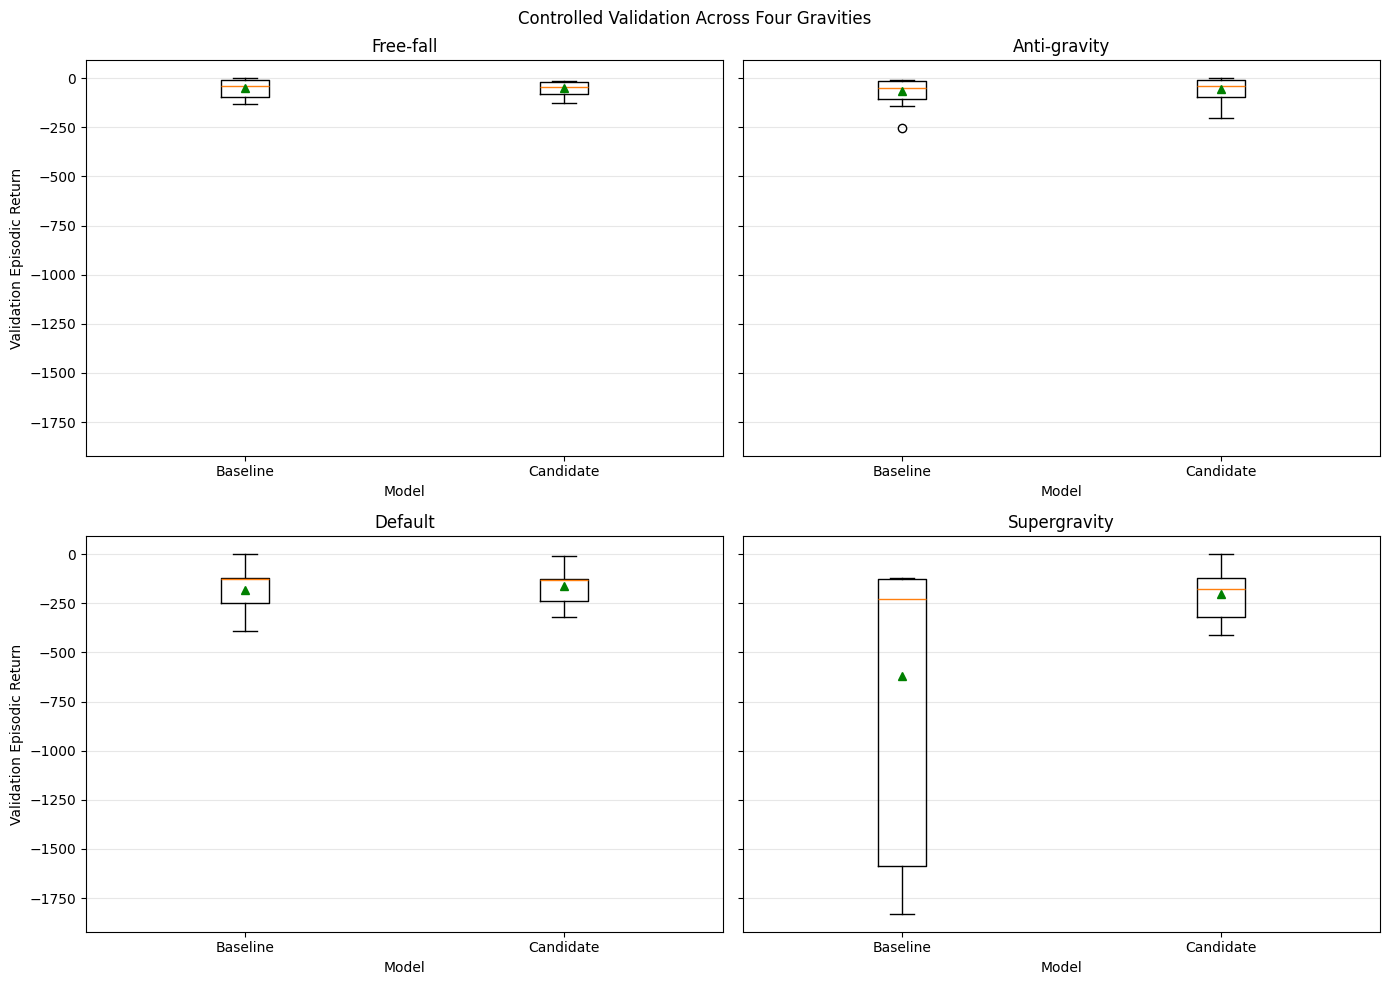

In [29]:
if validation_results:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

    for axis, gravity_name in zip(axes.flat, GRAVITY_SETTINGS):
        axis.boxplot(
            [
                validation_results[(gravity_name, "Baseline")],
                validation_results[(gravity_name, "Kayden Candidate")]
            ],
            tick_labels=["Baseline", "Candidate"],
            showmeans=True,
            meanprops={
                "marker": "^",
                "markerfacecolor": "green",
                "markeredgecolor": "green"
            }
        )
        axis.set_title(gravity_name)
        axis.set_xlabel("Model")
        axis.grid(axis="y", alpha=0.3)

    axes[0, 0].set_ylabel("Validation Episodic Return")
    axes[1, 0].set_ylabel("Validation Episodic Return")
    plt.suptitle("Controlled Validation Across Four Gravities")
    plt.tight_layout()
    plt.show()


## Candidate Summary for Group Comparison

The following cell summarises only Kayden's candidate across all four gravities. The other group member should produce the same measurements using the same common configuration and validation seeds.

The group should compare per-gravity means, average mean return, average standard deviation, number of gravity wins and worst-case performance before selecting one final architecture.


In [30]:
candidate_rows = [
    row for row in validation_summary
    if row["Model"] == "Kayden Candidate"
]

candidate_average_mean = np.mean([
    row["Mean"] for row in candidate_rows
])
candidate_average_std = np.mean([
    row["Std Dev"] for row in candidate_rows
])
candidate_worst_case = min([
    row["Worst"] for row in candidate_rows
])

print("Kayden Candidate — Four-Gravity Summary")
print(f"Average mean return : {candidate_average_mean:.2f}")
print(f"Average std dev     : {candidate_average_std:.2f}")
print(f"Worst single return : {candidate_worst_case:.2f}")

for row in candidate_rows:
    print(
        f"{row['Gravity']:<16} "
        f"Mean={row['Mean']:>8.2f}  "
        f"Std={row['Std Dev']:>8.2f}"
    )


Kayden Candidate — Four-Gravity Summary
Average mean return : -117.34
Average std dev     : 69.10
Worst single return : -412.17
Free-fall        Mean=  -51.59  Std=   37.38
Anti-gravity     Mean=  -52.49  Std=   52.42
Default          Mean= -160.98  Std=   78.58
Supergravity     Mean= -204.31  Std=  108.02


### Exporting Validation Returns

The raw validation returns are exported so that both candidates can later be compared in one notebook without retraining. This file contains development results, not final test results.


In [31]:
np.savez_compressed(
    "kayden_candidate_validation_returns.npz",
    free_fall=validation_results[("Free-fall", "Kayden Candidate")],
    anti_gravity=validation_results[("Anti-gravity", "Kayden Candidate")],
    default=validation_results[("Default", "Kayden Candidate")],
    supergravity=validation_results[("Supergravity", "Kayden Candidate")]
)

print("Saved: kayden_candidate_validation_returns.npz")


Saved: kayden_candidate_validation_returns.npz


## Current Conclusion

This notebook evaluates Kayden's candidate under the locked common configuration. It does **not** select the group’s final model yet.

The next step is to obtain the other candidate's validation returns from the same four gravities and seeds. Both candidate architectures can then be compared fairly. Only after the group selects one architecture should gravity-specific hyperparameter tuning begin. Final performance must be reported using the unseen seeds 2000–2029.
